In [1]:
import qcodes

from qcodes.dataset import (
    LinSweep,
    Measurement,
    dond,
    experiments,
    initialise_or_create_database_at,
    load_by_run_spec,
    load_or_create_experiment,
    plot_dataset,
)

import matplotlib.pyplot as plt
from matplotlib import cm, colors

import numpy as np
import pandas as df
import time

# Measurement summary:

## Run summary:

### Run 6
- GUID: 967f9bbd-0000-0000-0000-01a0882d77f4
- Parameters: N/A
- Frequency band(s): Wideband sweep from 2-10GHz. 
- Comments: Broad, unidentified mode around 8.5GHz.

### Run 10
- GUID: f28ad758-0000-0000-0000-01a08852be5d
- Parameters: 0V - +3V gate bias at ~100mK
- Frequency band(s): Sample.
- Comments: Mode begins to change close to 3V.

### Run 13
- GUID: 2c3c6564-0000-0000-0000-01a088a57f09
- Parameters: -3V - +3V gate bias
- Frequency band(s): Sample.
- Comments: Assymetric around ~1.5V.

### Run 15
- GUID: 5cbd12c7-0000-0000-0000-01a08d7fa0cb
- Parameters: -3V to +3V, base to 1K.
- Frequency band(s): Sample and references.
- Comments: 

### Run 16
- GUID: 1f13dd40-0000-0000-0000-01a09270f0cd
- Parameters: Gate 0V to 5V
- Frequency band(s): Sample and references.
- Comments: Change around 3V!

### Run 23
- GUID: de20c481-0000-0000-0000-01a0929e2cdd
- Parameters: Gate leakage check.
- Frequency band(s): N/A
- Comments: Gate turn-on around 7V. Terminated sweep at 7.75V. Need to create a function that sweeps all gates and sets software limits on the SMU output.

### Run 25
- GUID: d4df29e1-0000-0000-0000-01a09307d437
- Parameters: Power sweep at (I believe) 7V gate bias.
- Frequency band(s): Sample, references, wideband, mode.
- Comments: Unidentified mode is quite power-dependent. Is this consistent with box mode?

### Run 26
- GUID: 599ab6e7-0000-0000-0000-01a09402fef3
- Parameters: Temperature sweep up to 1K, 0 to 7V gate bias.
- Frequency band(s): Samples, references, mode.
- Comments: 

### Run 28
- GUID: 9a9d9c29-0000-0000-0000-01a09782b088
- Parameters: Negative gate sweep.
- Frequency band(s): N/A
- Comments: No leakage down to -5V on gate.

### Run 29
- GUID: f2c699fe-0000-0000-0000-01a097bbd2d7
- Parameters: Negative gate sweep at base temperature.
- Frequency band(s): Sample, references, wideband.
- Comments: Similar turn-on at negative doping. Second harmonic popping out!

### Run 31
- GUID: 03b6b17b-0000-0000-0000-01a098460236
- Parameters: -7V to +7V on gate, base temperature.
- Frequency band(s): Sample, sample harmonic, references, mode.
- Comments: 

### Run 32
- GUID: a30acff4-0000-0000-0000-01a09883a3f3
- Parameters: Power sweep -10dB to +10dB
- Frequency band(s): Sample, sample harmonic, references, mode.
- Comments: Not super power dependent.

### Run 32
- GUID: e8bfe9ef-0000-0000-0000-01a09896e39d
- Parameters: Lower power sweep -40dB to 0dB.
- Frequency band(s): Sample harmonic.
- Comments: 

### Run 34
- GUID: 5821ba49-0000-0000-0000-01a099b97b41
- Parameters: Warmer temperature sweep (1.4K-2.4K) at -7V to +7V gate bias.
- Frequency band(s): Sample, sample harmonic, references, mode.
- Comments: 

In [2]:
def load_band_2d(ds, name):
    """Return (gate [n], freq [m], s21 [n, m]) for one band."""
    d = ds.get_parameter_data(f"{name}_real", f"{name}_imag")
    re_block, im_block = d[f"{name}_real"], d[f"{name}_imag"]

    gate = re_block["gate"][:, 0]              # setpoint name; see note below
    freq = re_block[f"{name}_freq"][0, :]      # identical for every row
    s21 = re_block[f"{name}_real"] + 1j * im_block[f"{name}_imag"]
    return gate, freq, s21

def plot_linecuts_segment(ds, name, cmap="viridis", offset_db=0.0,
                          ax=None, segment=None,
                          detrend=None, edge_frac=0.15):
    """
    detrend : None | "full" | "edges"
        "full"  — least-squares line over every point in the segment
        "edges" — line fit to the outer `edge_frac` of points at each end,
                  so a resonance in the middle doesn't bias the baseline
    """
    gate, freq, s21 = load_band_2d(ds, name)

    if segment is not None:
        f_lo, f_hi = sorted(segment)
        mask = (freq >= f_lo) & (freq <= f_hi)
        if not mask.any():
            raise ValueError(
                f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                f"range {freq.min():.4g}–{freq.max():.4g} Hz"
            )
        freq = freq[mask]
        s21 = s21[:, mask]

    mag_db = 20 * np.log10(np.abs(s21))

    slopes = None
    if detrend:
        if freq.size < 2:
            raise ValueError("need at least 2 points in the segment to detrend")

        # center and scale x so the fit is well conditioned; slope is dB/GHz
        x = (freq - freq.mean()) / 1e9

        if detrend in (True, "full"):
            fit_mask = np.ones(freq.size, dtype=bool)
        elif detrend == "edges":
            n_edge = max(2, int(round(edge_frac * freq.size)))
            fit_mask = np.zeros(freq.size, dtype=bool)
            fit_mask[:n_edge] = True
            fit_mask[-n_edge:] = True
        else:
            raise ValueError(f"unknown detrend mode: {detrend!r}")

        # y shape (n_fit, n_gate) -> coeffs shape (2, n_gate)
        coeffs = np.polyfit(x[fit_mask], mag_db[:, fit_mask].T, 1)
        baseline = np.outer(coeffs[0], x) + coeffs[1][:, None]
        mag_db = mag_db - baseline
        slopes = coeffs[0]

    norm = colors.Normalize(vmin=gate.min(), vmax=gate.max())
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    for i, v in enumerate(gate):
        ax.plot(freq / 1e9, mag_db[i] + i * offset_db,
                color=sm.to_rgba(v), lw=0.9)

    ax.set_xlabel("Frequency (GHz)")
    ylabel = "|$S_{21}$| (dB)"
    if detrend:
        ylabel = "$\\Delta$|$S_{21}$| (dB, detrended)"
    ax.set_ylabel(ylabel + (" + offset" if offset_db else ""))

    title = f"{name} — run #{ds.captured_run_id}"
    if segment is not None:
        title += f"  [{f_lo/1e9:.3f}–{f_hi/1e9:.3f} GHz]"
    ax.set_title(title)

    ax.grid(alpha=0.25)

    cb = fig.colorbar(sm, ax=ax)
    cb.set_label("Gate Voltage (V)")
    fig.tight_layout()
    return fig, ax

In [3]:
def _detrend_along_freq(freq, mag_db, mode="edges", edge_frac=0.15):
    """
    mag_db : (n_freq, n_trace) — fits and removes a line down axis 0
             (frequency) independently for each column.
    Returns (detrended, slopes) with slopes in dB/GHz.
    """
    if freq.size < 2:
        raise ValueError("need at least 2 frequency points to detrend")

    x = (freq - freq.mean()) / 1e9   # centered + scaled: well conditioned

    if mode in (True, "full"):
        fit = np.ones(freq.size, dtype=bool)
    elif mode == "edges":
        n_edge = max(2, int(round(edge_frac * freq.size)))
        fit = np.zeros(freq.size, dtype=bool)
        fit[:n_edge] = True
        fit[-n_edge:] = True
    else:
        raise ValueError(f"unknown detrend mode: {mode!r}")

    y = mag_db[fit, :]
    if not np.isfinite(y).all():
        raise ValueError(
            "non-finite values in the fit window; polyfit would return NaN "
            "for those columns. Mask or interpolate them first."
        )

    coeffs = np.polyfit(x[fit], y, 1)            # (2, n_trace)
    baseline = np.outer(x, coeffs[0]) + coeffs[1]
    return mag_db - baseline, coeffs[0]


def plot_2d(ds, name, cmap=None, offset_db=0.0, ax=None,
            vmin=None, vmax=None, title=None,
            segment=None, detrend="edges", edge_frac=0.15,
            symmetric=True):
    gate, freq, s21 = load_band_2d(ds, name)
    mag_db = 20 * np.log10(np.abs(s21)) + offset_db

    # orient as (freq, gate): rows are frequency points, columns gate steps
    if mag_db.shape != (freq.size, gate.size):
        mag_db = mag_db.T
    if mag_db.shape != (freq.size, gate.size):
        raise ValueError(
            f"can't orient data of shape {mag_db.shape} to "
            f"(freq={freq.size}, gate={gate.size})"
        )

    if segment is not None:
        f_lo, f_hi = sorted(segment)
        fmask = (freq >= f_lo) & (freq <= f_hi)
        if not fmask.any():
            raise ValueError(
                f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                f"range {freq.min():.4g}–{freq.max():.4g} Hz"
            )
        freq = freq[fmask]
        mag_db = mag_db[fmask, :]

    slopes = None
    if detrend:
        mag_db, slopes = _detrend_along_freq(freq, mag_db, detrend, edge_frac)

    if cmap is None:
        cmap = "RdBu_r" if detrend else "viridis"

    if detrend and symmetric and vmin is None and vmax is None:
        lim = np.nanpercentile(np.abs(mag_db), 98)
        vmin, vmax = -lim, lim
    else:
        if vmin is None:
            vmin = np.nanpercentile(mag_db, 2)
        if vmax is None:
            vmax = np.nanpercentile(mag_db, 98)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)
    else:
        fig = ax.get_figure()

    mesh = ax.pcolormesh(
        gate, freq / 1e9, mag_db,
        cmap=cmap, shading="nearest",
        norm=colors.Normalize(vmin=vmin, vmax=vmax),
        rasterized=True,
    )

    cbar = fig.colorbar(mesh, ax=ax, pad=0.02)
    cbar.set_label(r"$\Delta|S_{21}|$  (dB)" if detrend
                   else r"$|S_{21}|$  (dB)")
    cbar.ax.tick_params(labelsize=9)

    ax.set_ylabel("Frequency (GHz)")
    ax.set_xlabel("Gate voltage (V)")
    ax.set_title(title or f"{name} — run #{ds.run_id}", pad=10)
    ax.tick_params(direction="out", length=4, top=False, right=False)
    for spine in ("top", "right"):
        ax.spines[spine].set_visible(False)

    ax._detrend_slopes = slopes
    return fig, ax

In [4]:
"""
Plotting helpers for the temperature / gate / frequency sweep produced by:

    result = dond(temp_sweep, gate_sweep,
                  smu.curr, tom.mxc_temperature,
                  *[p for b in bands for p in (b.acquire, b.real, b.imag)],
                  ...)

The measured mixing-chamber temperature is recorded as a *dependent* parameter
on the (setpoint, gate) grid, not as an axis.  SweepData pulls it out, averages
it over the gate axis at each outer step, and promotes it to a real coordinate
called "T" so both maps are plotted against measured temperature rather than
the PID setpoint.

Usage
-----
    sd = SweepData.from_dond(result)
    print(sd.summary())

    plot_freq_vs_gate(sd, "lambda2", temperature=0.150)   # nearest measured T
    plot_freq_vs_temp(sd, "lambda2", gate=-1.5)           # nearest gate value
"""

from __future__ import annotations

import numpy as np
import matplotlib.pyplot as plt

QUANTITIES = ("mag_db", "mag", "phase", "real", "imag")


# --------------------------------------------------------------------------
# name / dimension resolution
# --------------------------------------------------------------------------

def _find_one(keys, *fragments):
    """Return the single key containing all fragments (case-insensitive)."""
    frags = [f.lower() for f in fragments]
    hits = [k for k in keys if all(f in k.lower() for f in frags)]
    if len(hits) == 1:
        return hits[0]
    raise KeyError(
        f"expected exactly one parameter matching {fragments}, found {hits}. "
        f"Available: {sorted(keys)}"
    )


class SweepData:
    """Lazily-converted view of the dond dataset, keyed by band name."""

    def __init__(
        self,
        dataset,
        temp_param="mxc_temperature",
        temp_dim=None,
        gate_dim=None,
    ):
        self.dataset = dataset
        # One DataArray per dependent parameter.  Using the *dict* form rather
        # than to_xarray_dataset() matters here: the bands have different
        # numbers of frequency points (500/500/250), so a single merged
        # Dataset would pad everything to the longest axis with NaN.
        self.arrays = dataset.to_xarray_dataarray_dict()

        tkey = _find_one(self.arrays, temp_param)
        tda = self.arrays[tkey]
        if len(tda.dims) != 2:
            raise ValueError(
                f"expected {tkey} to live on a 2D (temperature, gate) grid, "
                f"got dims {tda.dims}"
            )

        # Work out which of the two grid dims is the temperature axis.
        if temp_dim is None:
            cand = [
                d for d in tda.dims
                if any(s in d.lower() for s in ("mxc", "setpoint", "temp"))
            ]
            if len(cand) != 1:
                raise ValueError(
                    f"could not identify the temperature dim among {tda.dims}; "
                    "pass temp_dim= and gate_dim= explicitly"
                )
            temp_dim = cand[0]
        if gate_dim is None:
            others = [d for d in tda.dims if d != temp_dim]
            gate_dim = others[0]

        self.temp_dim = temp_dim
        self.gate_dim = gate_dim

        # Measured temperature at each outer step, averaged over the gate
        # sweep (the inner loop runs at nominally fixed T).  The spread tells
        # you whether that average is meaningful.
        self._t_measured = tda.mean(dim=gate_dim, skipna=True)
        self._t_spread = (
            tda.max(dim=gate_dim, skipna=True) - tda.min(dim=gate_dim, skipna=True)
        )

        self.gate_values = np.asarray(tda.coords[gate_dim].values)
        self._band_cache = {}

    @classmethod
    def from_dond(cls, result, **kwargs):
        """Accept either the dond return tuple or a bare DataSet."""
        dataset = result[0] if isinstance(result, tuple) else result
        return cls(dataset, **kwargs)

    # -- temperature bookkeeping -------------------------------------------

    @property
    def temperatures(self):
        """Measured temperature per outer step, in setpoint order."""
        return np.asarray(self._t_measured.values)

    @property
    def temperature_spread(self):
        """max-min of measured T across the gate sweep, per outer step."""
        return np.asarray(self._t_spread.values)

    def summary(self):
        setp = np.asarray(self._t_measured.coords[self.temp_dim].values)
        lines = [f"{len(setp)} temperature steps, {len(self.gate_values)} gate points",
                 f"  {'setpoint':>12}  {'measured':>12}  {'spread':>10}"]
        for s, m, d in zip(setp, self.temperatures, self.temperature_spread):
            lines.append(f"  {s:>12.4g}  {m:>12.4g}  {d:>10.3g}")
        lines.append(f"bands: {', '.join(self.band_names())}")
        return "\n".join(lines)

    # -- band data ---------------------------------------------------------

    def band_names(self):
        return sorted(
            k.lower().rsplit("real", 1)[0].strip("_").rsplit("_", 0)[-1]
            for k in self.arrays if "real" in k.lower()
        )

    def band(self, name):
        """
        Complex S-parameter for one band, as an xarray.DataArray with dims
        ("T", <gate>, <frequency>), sorted by ascending measured temperature.
        """
        if name in self._band_cache:
            return self._band_cache[name]

        rkey = _find_one(self.arrays, name, "real")
        ikey = _find_one(self.arrays, name, "imag")
        da = self.arrays[rkey] + 1j * self.arrays[ikey]
        da.name = name

        missing = set(da.dims) - {self.temp_dim, self.gate_dim}
        if len(missing) != 1:
            raise ValueError(
                f"expected one frequency dim for band {name!r}, got {sorted(missing)}"
            )
        freq_dim = missing.pop()

        da = da.assign_coords({"T": (self.temp_dim, self.temperatures)})
        da = da.swap_dims({self.temp_dim: "T"}).sortby("T")
        da = da.transpose("T", self.gate_dim, freq_dim)
        da.attrs["freq_dim"] = freq_dim

        self._band_cache[name] = da
        return da


# --------------------------------------------------------------------------
# quantity extraction + shared plotting
# --------------------------------------------------------------------------

def _to_quantity(z, quantity, freq_dim=None, unwrap=False):
    if quantity == "mag_db":
        return 20 * np.log10(np.abs(z)), "|S| (dB)"
    if quantity == "mag":
        return np.abs(z), "|S| (lin.)"
    if quantity == "phase":
        ph = np.angle(z)
        if unwrap and freq_dim is not None:
            axis = z.dims.index(freq_dim)
            ph = np.unwrap(ph, axis=axis)
        return np.rad2deg(ph), "phase (deg)"
    if quantity == "real":
        return np.real(z), "Re S"
    if quantity == "imag":
        return np.imag(z), "Im S"
    raise ValueError(f"quantity must be one of {QUANTITIES}, got {quantity!r}")


def _draw(x, y_hz, values, *, xlabel, cbar_label, title, ax, cmap, vmin, vmax):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    mesh = ax.pcolormesh(
        x, np.asarray(y_hz) / 1e9, values,
        shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("frequency (GHz)")
    ax.set_title(title)
    cbar = ax.figure.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)
    return ax.figure, ax, mesh


# --------------------------------------------------------------------------
# the two maps
# --------------------------------------------------------------------------

def plot_freq_vs_gate(
    sd, band, temperature, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap="viridis", vmin=None, vmax=None,
):
    """
    Frequency (y) vs gate voltage (x) at the temperature step whose *measured*
    temperature is closest to `temperature`.

    Returns (fig, ax, mesh).  The temperature actually used is in the title
    and on mesh.actual_temperature.
    """
    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel(T=temperature, method="nearest")
    t_actual = float(sel.coords["T"].values)
    sel = sel.transpose(freq_dim, sd.gate_dim)

    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    fig, ax, mesh = _draw(
        np.asarray(sel.coords[sd.gate_dim].values),
        sel.coords[freq_dim].values,
        np.asarray(values),
        xlabel="gate voltage (V)",
        cbar_label=cbar_label,
        title=f"{band} — measured T = {t_actual:.4g} (requested {temperature:.4g})",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_temperature = t_actual
    return fig, ax, mesh


def plot_freq_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap="viridis", vmin=None, vmax=None,
):
    """
    Frequency (y) vs measured temperature (x) at the gate point closest to
    `gate`.

    The x axis is the measured MXC temperature, so the columns are not evenly
    spaced even though the setpoints were.  pcolormesh with shading="nearest"
    handles that correctly.

    Returns (fig, ax, mesh).  The gate value actually used is on
    mesh.actual_gate.
    """
    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)
    sel = sel.transpose(freq_dim, "T")

    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    fig, ax, mesh = _draw(
        np.asarray(sel.coords["T"].values),
        sel.coords[freq_dim].values,
        np.asarray(values),
        xlabel=f"measured MXC temperature ({sd.dataset.paramspecs[_find_one(sd.arrays, 'mxc_temperature')].unit or 'a.u.'})",
        cbar_label=cbar_label,
        title=f"{band} — gate = {g_actual:.4g} V (requested {gate:.4g} V)",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_gate = g_actual
    return fig, ax, mesh


def plot_linecuts_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    temperatures=None, offset=0.0, ax=None, cmap="viridis",
    legend=None, **plot_kw,
):
    """
    Same selection as plot_freq_vs_temp, drawn as overlaid line traces instead
    of a colour map: one curve per temperature step, coloured by measured
    temperature.

    Parameters beyond plot_freq_vs_temp:
        temperatures: subset of measured temperatures to draw (nearest match
            for each).  None draws every step.
        offset: vertical shift applied cumulatively per trace, for a waterfall.
            Units are whatever `quantity` is in (e.g. dB for "mag_db").
        legend: True forces a legend, False forces a colourbar.  Default picks
            a legend for <= 10 traces and a colourbar otherwise.

    Returns (fig, ax, lines).  The gate value actually used is on
    ax.actual_gate.
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)

    if temperatures is not None:
        wanted = np.atleast_1d(temperatures).astype(float)
        sel = sel.sel(T=list(wanted), method="nearest")
        # nearest-matching two close requests can land on the same step
        _, keep = np.unique(np.asarray(sel.coords["T"].values), return_index=True)
        sel = sel.isel(T=np.sort(keep))

    sel = sel.transpose("T", freq_dim)
    values, ylabel = _to_quantity(sel, quantity, freq_dim, unwrap_phase)
    values = np.asarray(values)

    tvals = np.asarray(sel.coords["T"].values)
    freq_ghz = np.asarray(sel.coords[freq_dim].values) / 1e9

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    cm = plt.get_cmap(cmap)
    lo, hi = float(np.min(tvals)), float(np.max(tvals))
    norm = Normalize(vmin=lo, vmax=hi if hi > lo else lo + 1.0)

    lines = []
    for i, t in enumerate(tvals):
        (line,) = ax.plot(
            freq_ghz, values[i] + i * offset,
            color=cm(norm(t)), label=f"T = {t:.4g}", **plot_kw,
        )
        lines.append(line)

    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel(ylabel + (" + offset" if offset else ""))
    ax.set_title(f"{band} — gate = {g_actual:.4g} V (requested {gate:.4g} V)")

    if legend is None:
        legend = len(tvals) <= 10
    if legend:
        ax.legend(fontsize="small", ncol=1 + len(tvals) // 12)
    else:
        sm = ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
        ax.figure.colorbar(sm, ax=ax).set_label("measured MXC temperature")

    ax.actual_gate = g_actual
    return ax.figure, ax, lines

In [151]:
# Fit Q's and frequencies at base temperature using a Lorentzian fit.
ds = qcodes.dataset.load_by_guid('03b6b17b-0000-0000-0000-01a098460236')
gate, freq, s21 = load_band_2d(ds,'sample')

In [177]:
def segment_freq_sweep(freq,s21,segment):
    if segment is not None:
            f_lo, f_hi = sorted(segment)
            mask = (freq >= f_lo) & (freq <= f_hi)
            if not mask.any():
                raise ValueError(
                    f"segment ({f_lo:.4g}, {f_hi:.4g}) Hz is outside the sweep "
                    f"range {freq.min():.4g}–{freq.max():.4g} Hz"
                )
            freq = freq[mask]
            s21 = s21[:, mask]
    return freq, s21

def neg_lorentzian(f, f0, fwhm, depth, offset):
    """
    Negative (dip) Lorentzian on a constant offset.

    f0     centre frequency
    fwhm   full width at half depth, same units as f
    depth  dip amplitude, from the offset down to the minimum
    offset baseline level

    Minimum value is offset - depth, at f = f0.  Q = f0 / fwhm.
    """
    return offset - depth / (1.0 + ((f - f0) / (0.5 * fwhm)) ** 2)

In [178]:
from scipy.optimize import curve_fit

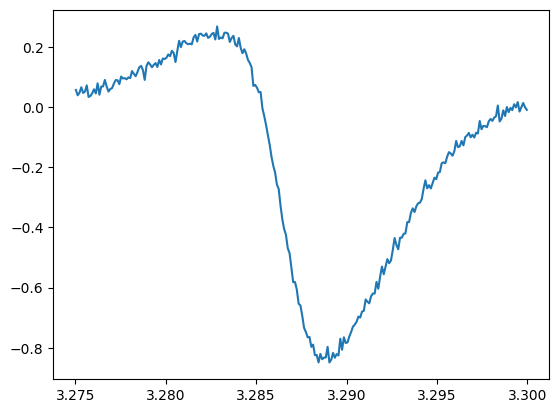

In [ ]:
ds = qcodes.dataset.load_by_guid('03b6b17b-0000-0000-0000-01a098460236')
gate, freq, s21 = load_band_2d(ds,'sample')

freq_seg, s21_seg = segment_freq_sweep(freq,s21,(3.275e9,3.30e9))
m,b = np.polyfit(freq_seg[-10:],10*np.log10(np.abs(s21_seg[0][-10:])**2),1)
s21_seg_detrended = 10*np.log10(np.abs(s21_seg[0])**2)-(m*freq_seg+b)

plt.figure(1)
plt.plot(freq_seg/1e9,s21_seg_detrended)

popt,_ = curve_fit(neg_lorentzian,freq_seg/1e9,s21_seg_detrended,p0=[3.285,0.01,0.5,0],maxfev=5000)
plt.plot(freq_seg/1e9,neg_lorentzian(freq_seg/1e9,*popt))
plt.plot(freq_seg/1e9,s21_seg_detrended)
popt

In [217]:
def neg_lorentzian_tilt(f, f0, fwhm, depth, offset, slope):
    return (offset + slope * (f - f0)
            - depth / (1.0 + ((f - f0) / (0.5 * fwhm)) ** 2))


def fit_q_row(freq_ghz, s21_row, n_edge=10):
    """Lorentzian dip in linear power, baseline fitted jointly.
    Returns (Q, f0_ghz, fwhm_ghz, depth_db, Q_err); NaNs if the fit fails."""
    nan = (np.nan,) * 5
    p = np.abs(np.asarray(s21_row)) ** 2
    good = np.isfinite(p) & (p > 0)
    if good.sum() < 8:
        return nan
    f, p = np.asarray(freq_ghz)[good], p[good]

    # wing line, used only to seed the fit
    n_edge = min(n_edge, max(2, len(f) // 4))
    w = np.r_[0:n_edge, len(f) - n_edge:len(f)]
    slope0, off0 = np.polyfit(f[w], p[w], 1)
    base = off0 + slope0 * f
    norm = p / np.where(base > 0, base, np.nanmax(p))
    i0 = int(np.argmin(norm))
    depth0 = float(np.clip(1.0 - norm[i0], 1e-4, 0.999))
    below = np.flatnonzero(norm < 1.0 - depth0 / 2.0)
    fwhm0 = (abs(f[below[-1]] - f[below[0]]) if below.size >= 2
             else 0.1 * (f[-1] - f[0]))
    fwhm0 = max(fwhm0, abs(f[1] - f[0]))
    base0 = float(off0 + slope0 * f[i0])

    span = f[-1] - f[0]
    p0 = [f[i0], fwhm0, depth0 * base0, base0, slope0]
    lo = [f[0] - span, 1e-9, 0.0, 0.0, -np.inf]
    hi = [f[-1] + span, 10 * span, np.inf, np.inf, np.inf]
    p0 = [float(np.clip(v, l + 1e-15, h)) for v, l, h in zip(p0, lo, hi)]

    try:
        popt, pcov = curve_fit(neg_lorentzian_tilt, f, p, p0=p0,
                               bounds=(lo, hi), maxfev=20000, x_scale="jac")
    except Exception:
        return nan

    f0, fwhm, depth, offset, _ = popt
    err = np.sqrt(np.abs(np.diag(pcov)))
    Q = f0 / fwhm
    Q_err = Q * np.hypot(err[0] / f0, err[1] / fwhm)
    frac = np.clip(1.0 - depth / offset, 1e-12, None) if offset > 0 else np.nan
    return Q, f0, fwhm, 10.0 * np.log10(frac), Q_err


def fit_q_vs_gate(gate, freq, s21, n_edge=10):
    freq_ghz = np.asarray(freq, dtype=float) / 1e9
    s21, gate = np.asarray(s21), np.asarray(gate, dtype=float)
    if s21.shape != (gate.size, freq_ghz.size):
        raise ValueError(
            f"expected s21 shaped (n_gate={gate.size}, n_freq={freq_ghz.size}), "
            f"got {s21.shape}")
    out = np.array([fit_q_row(freq_ghz, row, n_edge) for row in s21])
    return {"gate": gate, "Q": out[:, 0], "f0": out[:, 1], "fwhm": out[:, 2],
            "depth_db": out[:, 3], "Q_err": out[:, 4]}

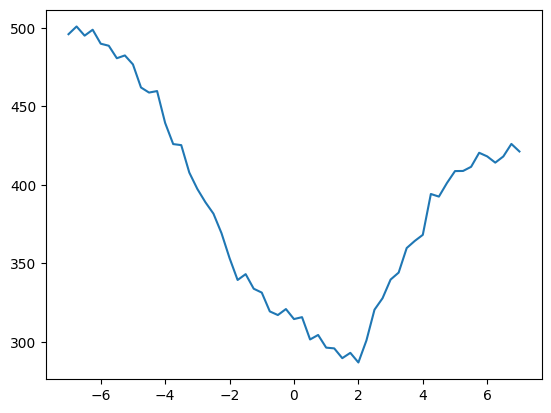

In [224]:
results = fit_q_vs_gate(gate,freq_seg,s21_seg)
gate_arr, q_arr, f0_arr = results['gate'], results['Q'], results['f0']
plt.plot(gate_arr,q_arr)

array([3.29003973, 0.00711648, 1.08392394, 0.23209709])

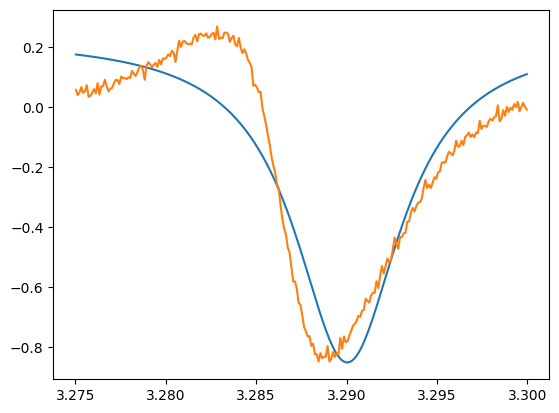

In [216]:
popt,_ = curve_fit(neg_lorentzian,freq_seg/1e9,s21_seg_detrended,p0=[3.285,0.01,0.5,0],maxfev=5000)
plt.plot(freq_seg/1e9,neg_lorentzian(freq_seg/1e9,*popt))
plt.plot(freq_seg/1e9,s21_seg_detrended)
popt

In [239]:
"""
Q from asymmetric (mismatched) resonator dips, row by row.

A notch resonance seen through a real line is

    S21 = 1 - a*exp(i*phi) / (1 + i*x),     x = 2*Q*(f-f0)/f0

where phi is the rotation caused by impedance mismatch.  Its squared
magnitude is exactly a Lorentzian plus a *dispersive* term,

    |S21|^2 = 1 - (C + E*x) / (1 + x^2),
        C = 2*a*cos(phi) - a^2,   E = 2*a*sin(phi)

so the asymmetry costs one extra linear parameter, not a different model.
E = 0 recovers the symmetric dip.  Q is still the width parameter of the
underlying resonance, not the apparent width of the skewed dip.
"""

import numpy as np
import matplotlib.pyplot as plt
from scipy.optimize import curve_fit


def fano_dip(f, f0, fwhm, C, E, offset, slope):
    """Asymmetric dip in linear power on a straight baseline."""
    x = 2.0 * (f - f0) / fwhm
    return (offset + slope * (f - f0)) * (1.0 - (C + E * x) / (1.0 + x * x))


def _unpack_asymmetry(C, E):
    """(C, E) -> (a, phi in degrees); NaN if outside the physical branch."""
    v = E / 2.0
    disc = 1.0 - v * v - C
    if disc < 0:
        return np.nan, np.nan
    u = 1.0 - np.sqrt(disc)
    return float(np.hypot(u, v)), float(np.degrees(np.arctan2(v, u)))


def fit_q_row(freq_ghz, s21_row, n_edge=10, symmetric=False):
    """
    Fit one trace.  Returns a dict with Q, f0, fwhm, depth_db, phi_deg,
    asymmetry E, Q_err and rms residual; values are NaN if the fit fails.
    """
    nan = dict(Q=np.nan, f0=np.nan, fwhm=np.nan, depth_db=np.nan,
               phi_deg=np.nan, E=np.nan, Q_err=np.nan, rms=np.nan)

    p = np.abs(np.asarray(s21_row)) ** 2
    good = np.isfinite(p) & (p > 0)
    if good.sum() < 10:
        return nan
    f, p = np.asarray(freq_ghz)[good], p[good]

    # seed from the wings; contamination here only affects the guess
    n_edge = min(n_edge, max(2, len(f) // 4))
    w = np.r_[0:n_edge, len(f) - n_edge:len(f)]
    slope0, off0 = np.polyfit(f[w], p[w], 1)
    base = off0 + slope0 * f
    norm = p / np.where(base > 0, base, np.nanmax(p))
    i0 = int(np.argmin(norm))
    C0 = float(np.clip(1.0 - norm[i0], 1e-4, 1.5))
    below = np.flatnonzero(norm < 1.0 - C0 / 2.0)
    fwhm0 = (abs(f[below[-1]] - f[below[0]]) if below.size >= 2
             else 0.1 * (f[-1] - f[0]))
    fwhm0 = max(fwhm0, abs(f[1] - f[0]))

    span = f[-1] - f[0]
    p0 = [f[i0], fwhm0, C0, 0.0, float(off0 + slope0 * f[i0]), slope0]
    lo = [f[0] - span, 1e-9, 0.0, -2.0, 0.0, -np.inf]
    hi = [f[-1] + span, 10 * span, 2.0, 2.0, np.inf, np.inf]
    if symmetric:
        lo[3], hi[3], p0[3] = -1e-12, 1e-12, 0.0
    p0 = [float(np.clip(v, l + 1e-15, h - 1e-15)) for v, l, h in zip(p0, lo, hi)]

    try:
        popt, pcov = curve_fit(fano_dip, f, p, p0=p0, bounds=(lo, hi),
                               maxfev=40000, x_scale="jac")
    except Exception:
        return nan

    f0, fwhm, C, E, offset, _ = popt
    err = np.sqrt(np.abs(np.diag(pcov)))
    Q = f0 / fwhm
    a, phi = _unpack_asymmetry(C, E)
    resid = p - fano_dip(f, *popt)

    # on-resonance depth of the skewed dip, relative to its own baseline
    x = 2.0 * (f - f0) / fwhm
    frac = float(np.clip(np.min(1.0 - (C + E * x) / (1.0 + x * x)), 1e-12, None))

    return dict(
        Q=Q, f0=f0, fwhm=fwhm, depth_db=10.0 * np.log10(frac),
        phi_deg=phi, E=E,
        Q_err=Q * np.hypot(err[0] / f0, err[1] / fwhm),
        rms=float(np.sqrt(np.mean(resid ** 2)) / offset),
    )


def fit_q_vs_gate(gate, freq, s21, n_edge=10, symmetric=False):
    """Fit every row of s21.  Returns a dict of arrays, one entry per gate."""
    freq_ghz = np.asarray(freq, dtype=float) / 1e9
    s21 = np.asarray(s21)
    gate = np.asarray(gate, dtype=float)
    if s21.shape != (gate.size, freq_ghz.size):
        raise ValueError(
            f"expected s21 shaped (n_gate={gate.size}, n_freq={freq_ghz.size}), "
            f"got {s21.shape}"
        )
    rows = [fit_q_row(freq_ghz, r, n_edge, symmetric) for r in s21]
    out = {k: np.array([r[k] for r in rows]) for k in rows[0]}
    out["gate"] = gate
    return out

from typing import Literal
def plot_q_vs_gate(res, param: list[Literal['Q','f0']],ax=None, show_phi=True, **kw):
    """Q against gate, with the fitted asymmetry angle on a second axis."""
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 4.5), constrained_layout=True)
    ok = np.isfinite(res[param])
    ax.plot(res['gate'],res[param],label=f"${param}$")
    # ax.errorbar(res["gate"][ok], res[param][ok], yerr=res[f"{param}_err"][ok],
    #             fmt="o-", ms=4, lw=1, capsize=2, label=f"${param}$", **kw)
    ax.set_xlabel("Gate voltage (V)")
    ax.set_ylabel(f"{param}")
    ax.grid(alpha=0.25)

    if show_phi and np.isfinite(res["phi_deg"]).any():
        ax2 = ax.twinx()
        ax2.plot(res["gate"][ok], res["phi_deg"][ok], "s--", ms=3, lw=.8,
                 color="tab:red", alpha=.6)
        ax2.set_ylabel(r"asymmetry $\phi$ (deg)", color="tab:red")
        ax2.tick_params(axis="y", colors="tab:red")

    n_bad = int((~ok).sum())
    if n_bad:
        ax.set_title(f"{n_bad} of {ok.size} traces failed to fit")
    return ax.figure, ax

[3.28723904 3.28730739 3.28736878 3.28745568 3.28747829 3.28754733
 3.28764507 3.28775043 3.28772246 3.28781056 3.28797165 3.28811792
 3.28823381 3.28818909 3.28835771 3.28845773 3.28846817 3.28848206
 3.28859356 3.28860482 3.28859876 3.28871214 3.28858876 3.28870624
 3.28883525 3.28870707 3.28870354 3.28886065 3.28868693 3.28871614
 3.28880239 3.28893332 3.28872709 3.28884625 3.28876693 3.28902546
 3.28887007 3.28876026 3.28854104 3.2881241  3.28787801 3.28774755
 3.28748476 3.28733189 3.28708469 3.2871579  3.28700308 3.2869418
 3.2868506  3.28685689 3.28672685 3.28674729 3.28662187 3.28654343
 3.28650927 3.28648507 3.28647002]


(<Figure size 700x450 with 1 Axes>,
 <Axes: xlabel='Gate voltage (V)', ylabel='Q'>)

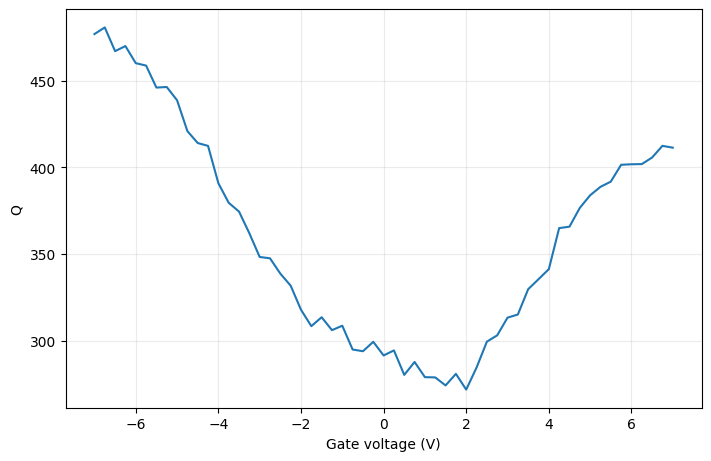

In [242]:
out = fit_q_vs_gate(gate,freq_seg,s21_seg)
print(out['f0'])
plot_q_vs_gate(out,param='Q',show_phi=False)

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — run #31  [3.275–3.300 GHz]'}, xlabel='Frequency (GHz)', ylabel='$\\Delta$|$S_{21}$| (dB, detrended)'>)

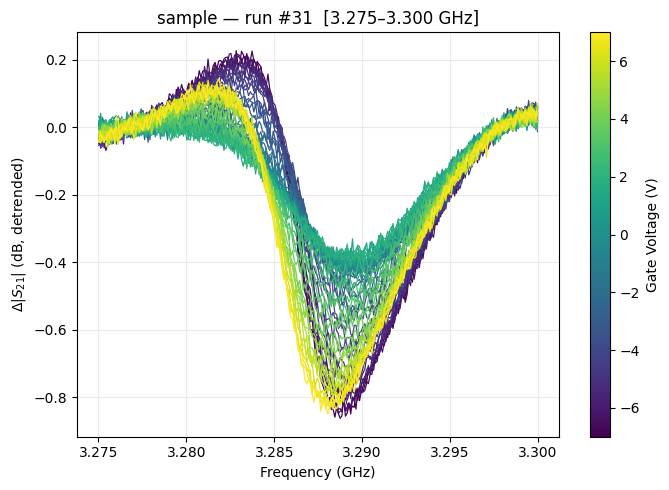

In [146]:
plot_linecuts_segment(ds,'sample',segment=(3.275e9,3.300e9),detrend='edges')

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — run #31'}, xlabel='Gate voltage (V)', ylabel='Frequency (GHz)'>)

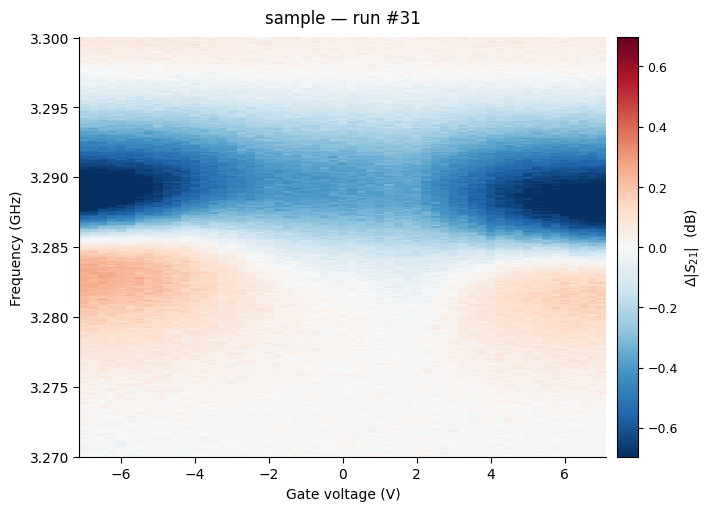

In [129]:
plot_2d(ds,'sample',segment=(3.27e9,3.3e9))

In [11]:
"""
Plotting helpers for the temperature / gate / frequency sweep produced by:

    result = dond(temp_sweep, gate_sweep,
                  smu.curr, tom.mxc_temperature,
                  *[p for b in bands for p in (b.acquire, b.real, b.imag)],
                  ...)

The measured mixing-chamber temperature is recorded as a *dependent* parameter
on the (setpoint, gate) grid, not as an axis.  SweepData pulls it out, averages
it over the gate axis at each outer step, and promotes it to a real coordinate
called "T" so both maps are plotted against measured temperature rather than
the PID setpoint.

Band names
----------
A band is identified by the *full* parameter name up to its "_real" / "_imag"
suffix, so "sample_lambda2_real" belongs to band "sample_lambda2".  Names are
matched exactly, which keeps bands that share a prefix -- "sample_a" and
"sample_a_wide", say -- from being confused with one another.  band_names()
lists what a run actually contains; pass one of those strings to the plotting
functions.  Override the suffixes with SweepData(..., component_suffixes=...)
if a setup labels the two halves differently.

Usage
-----
    sd = SweepData.from_dond(result)
    print(sd.summary())
    print(sd.band_names())        # e.g. ['sample_lambda2', 'sample_lambda3']

    plot_freq_vs_gate(sd, "lambda2", temperature=0.150)   # nearest measured T
    plot_freq_vs_temp(sd, "lambda2", gate=-1.5)           # nearest gate value

Each map has a line-cut counterpart taking the same selection argument, with
one trace per step of the other axis:

    plot_linecuts_vs_gate(sd, "lambda2", temperature=0.150,
                          gates=[-2.0, -1.5, -1.0, -0.5, 0.0])
    plot_linecuts_vs_temp(sd, "lambda2", gate=-1.5)

Zooming and baseline removal
----------------------------
Every plotting function takes:

    segment=(f_lo, f_hi)    frequency window in **Hz**, e.g. (6e9, 7e9)
    detrend="edges"         fit and subtract a line in frequency, independently
                            for each column (each gate step or each temperature
                            step), leaving deviation from the local baseline
    edge_frac=0.15          fraction of points at each end used for the fit
                            when detrend="edges"

    plot_freq_vs_gate(sd, "lambda2", temperature=0.150,
                      segment=(6e9, 7e9), detrend="edges")

detrend="full" fits over every point in the segment instead.  Prefer "edges"
whenever a resonance sits inside the window: a full-span fit is pulled toward
the dip, so subtraction leaves a spurious slope that moves with the resonance.

The fitted slopes (dB/GHz, or deg/GHz for phase) are attached to the returned
mesh as ``mesh.detrend_slopes`` (``ax.detrend_slopes`` for the line plots), one
per column.  They should be nearly constant; structure in them usually means
the fit window is catching the resonance.
"""

from __future__ import annotations

import warnings

import numpy as np
import matplotlib.pyplot as plt

QUANTITIES = ("mag_db", "mag", "phase", "real", "imag")

DETREND_MODES = (None, False, True, "full", "edges")

# Trailing markers that identify the two halves of a complex S-parameter.
# Lower-case keys; parameter names are matched case-insensitively.
COMPONENT_SUFFIXES = {"_real": "real", "_imag": "imag"}


# --------------------------------------------------------------------------
# name / dimension resolution
# --------------------------------------------------------------------------

def _find_one(keys, *fragments):
    """
    Return the single key containing all fragments (case-insensitive).

    Substring matching, so only safe for names that cannot be a prefix of one
    another -- used for the temperature parameter, not for bands.
    """
    frags = [f.lower() for f in fragments]
    hits = [k for k in keys if all(f in k.lower() for f in frags)]
    if len(hits) == 1:
        return hits[0]
    raise KeyError(
        f"expected exactly one parameter matching {fragments}, found {hits}. "
        f"Available: {sorted(keys)}"
    )


def _split_component(key, suffixes=COMPONENT_SUFFIXES):
    """
    Split a parameter name into (band, component) on a trailing "_real" or
    "_imag", or return (None, None) if it is not an S-parameter component.

    The band name is *everything* before the suffix, with its original case
    preserved, so "sample_lambda2_real" -> ("sample_lambda2", "real") and two
    bands sharing a "sample_" prefix stay distinct.  Matching the suffix at
    the end rather than anywhere in the string also keeps a parameter like
    "realtime_monitor" from being mistaken for a component.
    """
    low = key.lower()
    for suffix, component in suffixes.items():
        if low.endswith(suffix) and len(key) > len(suffix):
            return key[: len(key) - len(suffix)], component
    return None, None


def _index_components(keys, suffixes=COMPONENT_SUFFIXES):
    """Map band name -> {"real": key, "imag": key} for every component found."""
    found = {}
    for key in keys:
        band, component = _split_component(key, suffixes)
        if band is None:
            continue
        slot = found.setdefault(band, {})
        if component in slot:
            raise KeyError(
                f"two parameters both look like the {component!r} component of "
                f"band {band!r}: {slot[component]!r} and {key!r}"
            )
        slot[component] = key
    return found


class SweepData:
    """Lazily-converted view of the dond dataset, keyed by band name."""

    def __init__(
        self,
        dataset,
        temp_param="mxc_temperature",
        temp_dim=None,
        gate_dim=None,
        component_suffixes=None,
    ):
        self.dataset = dataset
        # One DataArray per dependent parameter.  Using the *dict* form rather
        # than to_xarray_dataset() matters here: the bands have different
        # numbers of frequency points (500/500/250), so a single merged
        # Dataset would pad everything to the longest axis with NaN.
        self.arrays = dataset.to_xarray_dataarray_dict()

        self.component_suffixes = dict(component_suffixes or COMPONENT_SUFFIXES)

        # band name -> {"real": param, "imag": param}, resolved once so that
        # band lookup is an exact dict hit rather than a substring search.
        self._components = _index_components(self.arrays, self.component_suffixes)
        incomplete = {
            b: sorted(c) for b, c in self._components.items() if len(c) < 2
        }
        if incomplete:
            warnings.warn(
                "ignoring band(s) with a missing component: "
                + ", ".join(f"{b} (has only {c})" for b, c in incomplete.items())
            )

        self.temp_key = _find_one(self.arrays, temp_param)
        tkey = self.temp_key
        tda = self.arrays[tkey]
        if len(tda.dims) != 2:
            raise ValueError(
                f"expected {tkey} to live on a 2D (temperature, gate) grid, "
                f"got dims {tda.dims}"
            )

        # Work out which of the two grid dims is the temperature axis.
        if temp_dim is None:
            cand = [
                d for d in tda.dims
                if any(s in d.lower() for s in ("mxc", "setpoint", "temp"))
            ]
            if len(cand) != 1:
                raise ValueError(
                    f"could not identify the temperature dim among {tda.dims}; "
                    "pass temp_dim= and gate_dim= explicitly"
                )
            temp_dim = cand[0]
        if gate_dim is None:
            others = [d for d in tda.dims if d != temp_dim]
            gate_dim = others[0]

        self.temp_dim = temp_dim
        self.gate_dim = gate_dim

        # Measured temperature at each outer step, averaged over the gate
        # sweep (the inner loop runs at nominally fixed T).  The spread tells
        # you whether that average is meaningful.
        self._t_measured = tda.mean(dim=gate_dim, skipna=True)
        self._t_spread = (
            tda.max(dim=gate_dim, skipna=True) - tda.min(dim=gate_dim, skipna=True)
        )

        self.gate_values = np.asarray(tda.coords[gate_dim].values)
        self._band_cache = {}

    @classmethod
    def from_dond(cls, result, **kwargs):
        """Accept either the dond return tuple or a bare DataSet."""
        dataset = result[0] if isinstance(result, tuple) else result
        return cls(dataset, **kwargs)

    # -- temperature bookkeeping -------------------------------------------

    @property
    def temperatures(self):
        """Measured temperature per outer step, in setpoint order."""
        return np.asarray(self._t_measured.values)

    @property
    def temperature_spread(self):
        """max-min of measured T across the gate sweep, per outer step."""
        return np.asarray(self._t_spread.values)

    def summary(self):
        setp = np.asarray(self._t_measured.coords[self.temp_dim].values)
        lines = [f"{len(setp)} temperature steps, {len(self.gate_values)} gate points",
                 f"  {'setpoint':>12}  {'measured':>12}  {'spread':>10}"]
        for s, m, d in zip(setp, self.temperatures, self.temperature_spread):
            lines.append(f"  {s:>12.4g}  {m:>12.4g}  {d:>10.3g}")
        lines.append(f"bands: {', '.join(self.band_names())}")
        return "\n".join(lines)

    # -- band data ---------------------------------------------------------

    def band_names(self):
        """
        Full band names, i.e. the whole parameter name up to the "_real" /
        "_imag" suffix.  Bands sharing a prefix stay separate, so a run with
        "sample_a_real" and "sample_b_real" reports ["sample_a", "sample_b"].
        """
        return sorted(
            band for band, comp in self._components.items() if len(comp) == 2
        )

    def components(self, name):
        """The underlying parameter names for one band, as a dict."""
        return dict(self._components[self._resolve_band(name)])

    def _resolve_band(self, name):
        """
        Exact band name, with a case-insensitive fallback.

        Deliberately not a substring match: with bands named "sample_a" and
        "sample_a_wide", a substring search for "sample_a" hits both, and
        whichever one it picked would be a coin toss.
        """
        if name in self._components:
            return name

        ci = [b for b in self._components if b.lower() == name.lower()]
        if len(ci) == 1:
            return ci[0]

        available = sorted(self._components)
        near = [b for b in available if name.lower() in b.lower()]
        hint = (
            f" Did you mean one of {near}? Band names are now the full "
            "parameter name up to the component suffix, so pass it in full."
            if near else f" Available bands: {available}."
        )
        raise KeyError(f"no band named {name!r}.{hint}")

    def band(self, name):
        """
        Complex S-parameter for one band, as an xarray.DataArray with dims
        ("T", <gate>, <frequency>), sorted by ascending measured temperature.

        `name` must be the full band name as reported by band_names().
        """
        name = self._resolve_band(name)
        if name in self._band_cache:
            return self._band_cache[name]

        comp = self._components[name]
        missing = sorted({"real", "imag"} - set(comp))
        if missing:
            raise KeyError(
                f"band {name!r} has no {missing} component; found only "
                f"{sorted(comp.values())}"
            )

        rkey, ikey = comp["real"], comp["imag"]
        rda, ida = self.arrays[rkey], self.arrays[ikey]
        if rda.dims != ida.dims or rda.shape != ida.shape:
            # xarray would broadcast these into something plausible-looking
            raise ValueError(
                f"band {name!r}: {rkey!r} has dims {rda.dims} {rda.shape} but "
                f"{ikey!r} has {ida.dims} {ida.shape}"
            )

        da = rda + 1j * ida
        da.name = name

        missing = set(da.dims) - {self.temp_dim, self.gate_dim}
        if len(missing) != 1:
            raise ValueError(
                f"expected one frequency dim for band {name!r}, got {sorted(missing)}"
            )
        freq_dim = missing.pop()

        da = da.assign_coords({"T": (self.temp_dim, self.temperatures)})
        da = da.swap_dims({self.temp_dim: "T"}).sortby("T")
        da = da.transpose("T", self.gate_dim, freq_dim)
        da.attrs["freq_dim"] = freq_dim

        self._band_cache[name] = da
        return da


# --------------------------------------------------------------------------
# quantity extraction
# --------------------------------------------------------------------------

def _to_quantity(z, quantity, freq_dim=None, unwrap=False):
    if quantity == "mag_db":
        return 20 * np.log10(np.abs(z)), "|S| (dB)"
    if quantity == "mag":
        return np.abs(z), "|S| (lin.)"
    if quantity == "phase":
        ph = np.angle(z)
        if unwrap and freq_dim is not None:
            axis = z.dims.index(freq_dim)
            ph = np.unwrap(ph, axis=axis)
        return np.rad2deg(ph), "phase (deg)"
    if quantity == "real":
        return np.real(z), "Re S"
    if quantity == "imag":
        return np.imag(z), "Im S"
    raise ValueError(f"quantity must be one of {QUANTITIES}, got {quantity!r}")


# --------------------------------------------------------------------------
# segmenting + linear detrending
# --------------------------------------------------------------------------

def _segment_mask(freq_hz, segment):
    """Boolean mask selecting f_lo <= f <= f_hi.  Bounds are in Hz."""
    try:
        lo, hi = (float(v) for v in segment)
    except (TypeError, ValueError):
        raise ValueError(
            f"segment must be a pair of frequencies in Hz, got {segment!r}"
        ) from None
    lo, hi = min(lo, hi), max(lo, hi)

    fmax = float(np.nanmax(np.abs(freq_hz)))
    if fmax > 1e6 and max(abs(lo), abs(hi)) < 1e6:
        raise ValueError(
            f"segment {segment!r} looks like GHz but the frequency axis is in "
            f"Hz (up to {fmax:.4g}); pass e.g. (6e9, 7e9)"
        )

    mask = (freq_hz >= lo) & (freq_hz <= hi)
    if not mask.any():
        raise ValueError(
            f"segment ({lo:.6g}, {hi:.6g}) Hz selects no points; the band "
            f"covers {np.nanmin(freq_hz):.6g}-{fmax:.6g} Hz"
        )
    if mask.sum() < 2:
        raise ValueError(
            f"segment ({lo:.6g}, {hi:.6g}) Hz selects only one frequency "
            "point; widen it"
        )
    return mask, lo, hi


def _fit_mask(n, mode, edge_frac):
    """Which frequency points feed the baseline fit."""
    if mode in (True, "full"):
        return np.ones(n, dtype=bool)
    if mode == "edges":
        n_edge = max(2, int(round(edge_frac * n)))
        if 2 * n_edge >= n:
            warnings.warn(
                f"edge_frac={edge_frac} leaves no gap between the two fit "
                f"windows for {n} points; falling back to a full-span fit",
                stacklevel=3,
            )
            return np.ones(n, dtype=bool)
        fit = np.zeros(n, dtype=bool)
        fit[:n_edge] = True
        fit[-n_edge:] = True
        return fit
    raise ValueError(
        f"detrend must be one of {DETREND_MODES}, got {mode!r}"
    )


def _detrend_along_freq(freq_hz, values, mode="edges", edge_frac=0.15):
    """
    Fit and remove a line in frequency, independently for each column.

    freq_hz : (n_freq,)
    values  : (n_freq, n_col)   one column per gate step / temperature step

    Returns (detrended, slopes) with slopes in <unit>/GHz.  A column with
    fewer than two finite points in the fit window is left untouched and
    reports a NaN slope.
    """
    freq_hz = np.asarray(freq_hz, dtype=float)
    values = np.asarray(values, dtype=float)

    if values.ndim != 2 or values.shape[0] != freq_hz.size:
        raise ValueError(
            f"expected values shaped (n_freq={freq_hz.size}, n_col), "
            f"got {values.shape}"
        )
    if freq_hz.size < 2:
        raise ValueError("need at least 2 frequency points to fit a line")

    # Centre and scale the abscissa: keeps the Vandermonde matrix well
    # conditioned (raw Hz values ~1e10 do not) and makes the slope dB/GHz.
    x = (freq_hz - freq_hz.mean()) / 1e9

    fit = _fit_mask(freq_hz.size, mode, edge_frac)
    xf, yf = x[fit], values[fit, :]
    n_col = values.shape[1]

    if np.isfinite(yf).all():
        coeffs = np.polyfit(xf, yf, 1)          # -> (2, n_col)
        slope, intercept = coeffs[0], coeffs[1]
        reported = slope
    else:
        # polyfit propagates NaN across the whole batch, so fall back to a
        # per-column fit over the finite points only.
        slope = np.zeros(n_col)
        intercept = np.zeros(n_col)
        reported = np.full(n_col, np.nan)
        bad = []
        for j in range(n_col):
            good = np.isfinite(yf[:, j])
            if good.sum() >= 2:
                p = np.polyfit(xf[good], yf[good, j], 1)
                slope[j], intercept[j] = p
                reported[j] = p[0]
            else:
                bad.append(j)
        if bad:
            warnings.warn(
                f"{len(bad)} column(s) had fewer than 2 finite points in the "
                f"fit window and were left undetrended (first: {bad[0]})",
                stacklevel=3,
            )

    baseline = np.outer(x, slope) + intercept   # -> (n_freq, n_col)
    return values - baseline, reported


def _segment_and_detrend(freq_hz, values, segment, detrend, edge_frac):
    """
    Apply the frequency window then the per-column baseline removal.

    values must be (n_freq, n_col).  Returns
    (freq_hz, values, slopes, label) where label is a title suffix.
    """
    freq_hz = np.asarray(freq_hz, dtype=float)
    values = np.asarray(values, dtype=float)
    bits = []

    if segment is not None:
        mask, lo, hi = _segment_mask(freq_hz, segment)
        freq_hz = freq_hz[mask]
        values = values[mask, :]
        bits.append(f"{lo / 1e9:.4g}-{hi / 1e9:.4g} GHz")

    slopes = None
    if detrend:
        values, slopes = _detrend_along_freq(freq_hz, values, detrend, edge_frac)
        bits.append("detrended" if detrend == "edges" else f"detrended/{detrend}")

    label = f"  [{', '.join(bits)}]" if bits else ""
    return freq_hz, values, slopes, label


def _check_detrend_quantity(quantity, detrend, unwrap_phase):
    """Reject or flag combinations where a linear baseline is meaningless."""
    if not detrend:
        return
    if quantity == "phase" and not unwrap_phase:
        raise ValueError(
            "detrending wrapped phase fits a line through the 2*pi jumps. "
            "Pass unwrap_phase=True (the linear term is then the electrical "
            "delay, which is what you want removed)."
        )
    if quantity in ("real", "imag"):
        warnings.warn(
            f"quantity={quantity!r} oscillates with frequency, so a linear "
            "baseline has no clear physical meaning; detrending anyway",
            stacklevel=3,
        )


# --------------------------------------------------------------------------
# colour scaling + shared drawing
# --------------------------------------------------------------------------

def _color_limits(values, vmin, vmax, detrended, symmetric=True, pct=98.0):
    """Percentile limits, symmetric about zero once a baseline is removed."""
    if vmin is not None and vmax is not None:
        return vmin, vmax
    finite = values[np.isfinite(values)]
    if finite.size == 0:
        return vmin, vmax

    if detrended and symmetric and vmin is None and vmax is None:
        lim = float(np.percentile(np.abs(finite), pct))
        if lim == 0.0:
            lim = 1.0
        return -lim, lim

    if vmin is None:
        vmin = float(np.percentile(finite, 100.0 - pct))
    if vmax is None:
        vmax = float(np.percentile(finite, pct))
    return vmin, vmax


def _default_cmap(cmap, detrended):
    if cmap is not None:
        return cmap
    # Once the baseline is gone the data is a signed deviation about zero, so
    # a diverging map with the neutral colour at 0 reads correctly.
    return "RdBu_r" if detrended else "viridis"


def _draw(x, y_hz, values, *, xlabel, cbar_label, title, ax, cmap, vmin, vmax):
    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    mesh = ax.pcolormesh(
        x, np.asarray(y_hz) / 1e9, values,
        shading="nearest", cmap=cmap, vmin=vmin, vmax=vmax,
    )
    ax.set_xlabel(xlabel)
    ax.set_ylabel("frequency (GHz)")
    ax.set_title(title)
    cbar = ax.figure.colorbar(mesh, ax=ax)
    cbar.set_label(cbar_label)
    return ax.figure, ax, mesh


# --------------------------------------------------------------------------
# the two maps
# --------------------------------------------------------------------------

def plot_freq_vs_gate(
    sd, band, temperature, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap=None, vmin=None, vmax=None,
    segment=None, detrend=None, edge_frac=0.15, symmetric=True,
):
    """
    Frequency (y) vs gate voltage (x) at the temperature step whose *measured*
    temperature is closest to `temperature`.

    segment=(f_lo, f_hi) in Hz restricts the frequency axis.  detrend="edges"
    or "full" then removes a line in frequency from each gate column; see the
    module docstring.

    Returns (fig, ax, mesh).  The temperature actually used is in the title
    and on mesh.actual_temperature; the per-gate baseline slopes (or None) are
    on mesh.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel(T=temperature, method="nearest")
    t_actual = float(sel.coords["T"].values)
    sel = sel.transpose(freq_dim, sd.gate_dim)

    # Unwrapping happens on the full band, before any windowing, so a segment
    # boundary cannot introduce a fake 2*pi step.
    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    freq_hz, values, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values),
        segment, detrend, edge_frac,
    )
    if detrend:
        cbar_label = f"delta {cbar_label}"

    cmap = _default_cmap(cmap, bool(detrend))
    vmin, vmax = _color_limits(values, vmin, vmax, bool(detrend), symmetric)

    fig, ax, mesh = _draw(
        np.asarray(sel.coords[sd.gate_dim].values),
        freq_hz,
        values,
        xlabel="gate voltage (V)",
        cbar_label=cbar_label,
        title=f"{da.name} — measured T = {t_actual:.4g} "
              f"(requested {temperature:.4g}){label}",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_temperature = t_actual
    mesh.detrend_slopes = slopes
    return fig, ax, mesh


def plot_freq_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    ax=None, cmap=None, vmin=None, vmax=None,
    segment=None, detrend=None, edge_frac=0.15, symmetric=True,
):
    """
    Frequency (y) vs measured temperature (x) at the gate point closest to
    `gate`.

    The x axis is the measured MXC temperature, so the columns are not evenly
    spaced even though the setpoints were.  pcolormesh with shading="nearest"
    handles that correctly.

    segment=(f_lo, f_hi) in Hz restricts the frequency axis.  detrend removes
    a line in frequency from each *temperature* column, which also removes any
    temperature-dependent overall gain or loss — see the module docstring
    before using it here.

    Returns (fig, ax, mesh).  The gate value actually used is on
    mesh.actual_gate; the per-temperature baseline slopes (or None) are on
    mesh.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)
    sel = sel.transpose(freq_dim, "T")

    values, cbar_label = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    freq_hz, values, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values),
        segment, detrend, edge_frac,
    )
    if detrend:
        cbar_label = f"delta {cbar_label}"

    cmap = _default_cmap(cmap, bool(detrend))
    vmin, vmax = _color_limits(values, vmin, vmax, bool(detrend), symmetric)

    tunit = sd.dataset.paramspecs[sd.temp_key].unit or "a.u."

    fig, ax, mesh = _draw(
        np.asarray(sel.coords["T"].values),
        freq_hz,
        values,
        xlabel=f"measured MXC temperature ({tunit})",
        cbar_label=cbar_label,
        title=f"{da.name} — gate = {g_actual:.4g} V "
              f"(requested {gate:.4g} V){label}",
        ax=ax, cmap=cmap, vmin=vmin, vmax=vmax,
    )
    mesh.actual_gate = g_actual
    mesh.detrend_slopes = slopes
    return fig, ax, mesh


# --------------------------------------------------------------------------
# line cuts
# --------------------------------------------------------------------------

def _select_nearest_subset(sel, dim, wanted):
    """
    Keep only the steps closest to `wanted` along `dim`, de-duplicated and in
    ascending coordinate order.  Two nearby requests can match the same step.
    """
    wanted = np.atleast_1d(wanted).astype(float)
    sel = sel.sel({dim: list(wanted)}, method="nearest")
    _, keep = np.unique(np.asarray(sel.coords[dim].values), return_index=True)
    return sel.isel({dim: np.sort(keep)})


def _draw_linecuts(
    freq_hz, values, cvals, *, ylabel, cbar_label, label_fmt, title,
    ax, cmap, offset, legend, **plot_kw
):
    """
    One trace per row of `values` (shape (n_trace, n_freq)), coloured by the
    matching entry of `cvals`.  Shared by the gate and temperature versions.
    """
    from matplotlib.cm import ScalarMappable
    from matplotlib.colors import Normalize

    if ax is None:
        _, ax = plt.subplots(figsize=(7, 5), constrained_layout=True)

    freq_ghz = np.asarray(freq_hz) / 1e9
    cvals = np.asarray(cvals, dtype=float)

    cm = plt.get_cmap(cmap)
    lo, hi = float(np.nanmin(cvals)), float(np.nanmax(cvals))
    norm = Normalize(vmin=lo, vmax=hi if hi > lo else lo + 1.0)

    lines = []
    for i, c in enumerate(cvals):
        (line,) = ax.plot(
            freq_ghz, values[i] + i * offset,
            color=cm(norm(c)), label=label_fmt.format(c), **plot_kw,
        )
        lines.append(line)

    ax.set_xlabel("frequency (GHz)")
    ax.set_ylabel(ylabel + (" + offset" if offset else ""))
    ax.set_title(title)

    if legend is None:
        legend = len(cvals) <= 10
    if legend:
        ax.legend(fontsize="small", ncol=1 + len(cvals) // 12)
    else:
        sm = ScalarMappable(norm=norm, cmap=cm)
        sm.set_array([])
        ax.figure.colorbar(sm, ax=ax).set_label(cbar_label)

    return ax.figure, ax, lines


def plot_linecuts_vs_temp(
    sd, band, gate, *, quantity="mag_db", unwrap_phase=False,
    temperatures=None, offset=0.0, ax=None, cmap="viridis",
    legend=None, segment=None, detrend=None, edge_frac=0.15, **plot_kw,
):
    """
    Same selection as plot_freq_vs_temp, drawn as overlaid line traces instead
    of a colour map: one curve per temperature step, coloured by measured
    temperature.

    Parameters beyond plot_freq_vs_temp:
        temperatures: subset of measured temperatures to draw (nearest match
            for each).  None draws every step.
        offset: vertical shift applied cumulatively per trace, for a waterfall.
            Units are whatever `quantity` is in (e.g. dB for "mag_db").
        legend: True forces a legend, False forces a colourbar.  Default picks
            a legend for <= 10 traces and a colourbar otherwise.

    segment and detrend behave as in the maps; detrending is applied per trace
    before the waterfall offset, so the traces stack about their own baselines.

    Returns (fig, ax, lines).  The gate value actually used is on
    ax.actual_gate; the per-trace baseline slopes (or None) are on
    ax.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel({sd.gate_dim: gate}, method="nearest")
    g_actual = float(sel.coords[sd.gate_dim].values)

    if temperatures is not None:
        sel = _select_nearest_subset(sel, "T", temperatures)

    sel = sel.transpose("T", freq_dim)
    values, ylabel = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    # the shared helper works on (n_freq, n_col)
    freq_hz, values_fc, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values).T,
        segment, detrend, edge_frac,
    )
    if detrend:
        ylabel = f"delta {ylabel}"

    fig, ax, lines = _draw_linecuts(
        freq_hz, values_fc.T, np.asarray(sel.coords["T"].values),
        ylabel=ylabel,
        cbar_label="measured MXC temperature",
        label_fmt="T = {:.4g}",
        title=f"{da.name} — gate = {g_actual:.4g} V "
              f"(requested {gate:.4g} V){label}",
        ax=ax, cmap=cmap, offset=offset, legend=legend, **plot_kw,
    )

    ax.actual_gate = g_actual
    ax.detrend_slopes = slopes
    return fig, ax, lines


def plot_linecuts_vs_gate(
    sd, band, temperature, *, quantity="mag_db", unwrap_phase=False,
    gates=None, offset=0.0, ax=None, cmap="viridis",
    legend=None, segment=None, detrend=None, edge_frac=0.15, **plot_kw,
):
    """
    Same selection as plot_freq_vs_gate, drawn as overlaid line traces instead
    of a colour map: one curve per gate step at the temperature step whose
    *measured* temperature is closest to `temperature`, coloured by gate
    voltage.

    Parameters beyond plot_freq_vs_gate:
        gates: subset of gate values to draw (nearest match for each).  None
            draws every step, which is usually far too many to read -- pass a
            handful, or use plot_freq_vs_gate for the full map.
        offset: vertical shift applied cumulatively per trace, for a waterfall.
            Units are whatever `quantity` is in (e.g. dB for "mag_db").
        legend: True forces a legend, False forces a colourbar.  Default picks
            a legend for <= 10 traces and a colourbar otherwise.

    segment and detrend behave as in the maps; detrending is applied per trace
    before the waterfall offset, so the traces stack about their own baselines.

    Returns (fig, ax, lines).  The temperature actually used is on
    ax.actual_temperature; the per-trace baseline slopes (or None) are on
    ax.detrend_slopes.
    """
    _check_detrend_quantity(quantity, detrend, unwrap_phase)

    da = sd.band(band)
    freq_dim = da.attrs["freq_dim"]

    sel = da.sel(T=temperature, method="nearest")
    t_actual = float(sel.coords["T"].values)

    if gates is not None:
        sel = _select_nearest_subset(sel, sd.gate_dim, gates)

    sel = sel.transpose(sd.gate_dim, freq_dim)
    values, ylabel = _to_quantity(sel, quantity, freq_dim, unwrap_phase)

    freq_hz, values_fc, slopes, label = _segment_and_detrend(
        sel.coords[freq_dim].values, np.asarray(values).T,
        segment, detrend, edge_frac,
    )
    if detrend:
        ylabel = f"delta {ylabel}"

    gvals = np.asarray(sel.coords[sd.gate_dim].values)
    if gvals.ndim == 0:                     # a single gate step was requested
        gvals = gvals.reshape(1)

    fig, ax, lines = _draw_linecuts(
        freq_hz, values_fc.T, gvals,
        ylabel=ylabel,
        cbar_label="gate voltage (V)",
        label_fmt="$V_g$ = {:.4g} V",
        title=f"{da.name} — measured T = {t_actual:.4g} "
              f"(requested {temperature:.4g}){label}",
        ax=ax, cmap=cmap, offset=offset, legend=legend, **plot_kw,
    )

    ax.actual_temperature = t_actual
    ax.detrend_slopes = slopes
    return fig, ax, lines

In [13]:
ds = qcodes.dataset.load_by_run_spec(captured_run_id=34)
sd = SweepData(ds)

In [43]:
sd.summary()

'7 temperature steps, 53 gate points\n      setpoint      measured      spread\n          1200         1.257       0.174\n          1400           1.4     0.00859\n          1600           1.6       0.014\n          1800         1.801      0.0174\n          2000             2      0.0187\n          2200           2.2      0.0218\n          2400         2.401      0.0142\nbands: lambda2, lambda4, mode, sample, sample_firstharm'

C:\Users\eseye\AppData\Local\Temp\ipykernel_14992\2956810882.py:646: UserWarning: 1 column(s) had fewer than 2 finite points in the fit window and were left undetrended (first: 6)
  freq_hz, values, slopes, label = _segment_and_detrend(


(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — gate = 6 V (requested 6 V)  [3.27-3.3 GHz, detrended]'}, xlabel='measured MXC temperature (K)', ylabel='frequency (GHz)'>,
 <matplotlib.collections.QuadMesh at 0x23e85baa660>)

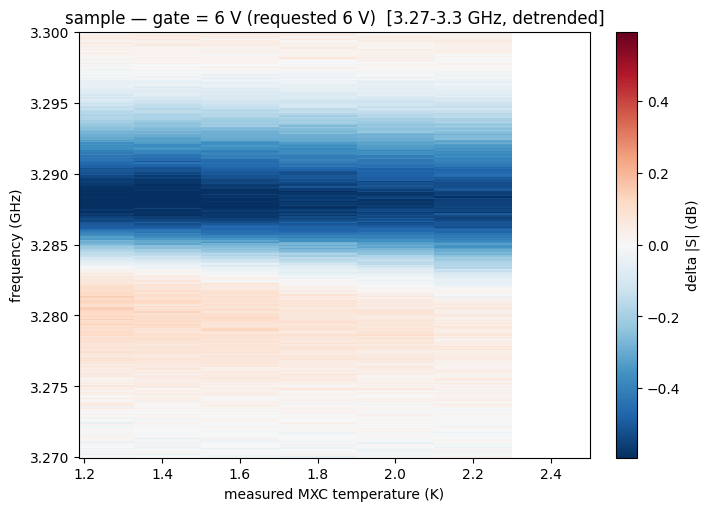

In [44]:
plot_freq_vs_temp(sd,'sample',gate = 6,detrend='edges',segment=(3.27e9,3.3e9))

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'lambda2 — gate = 0 V (requested 0 V)'}, xlabel='frequency (GHz)', ylabel='|S| (dB)'>,
  <matplotlib.lines.Line2D at 0x23ef73b97c0>])

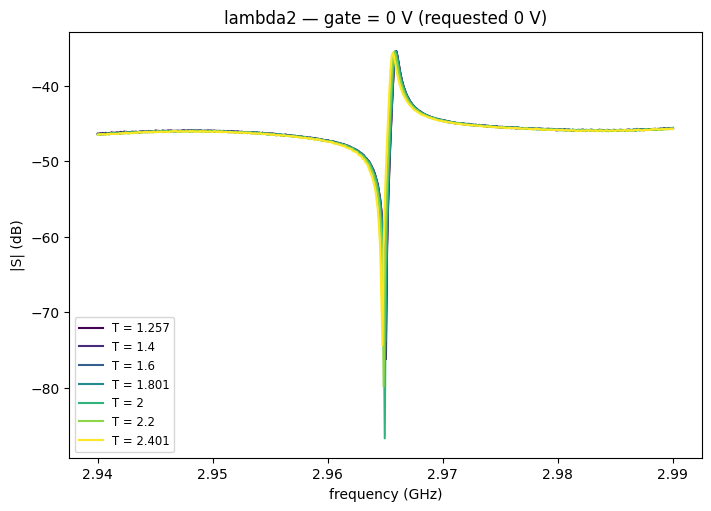

In [46]:
plot_linecuts_vs_temp(sd,'lambda2',gate=0,offset=0)

(<Figure size 700x500 with 1 Axes>,
 <Axes: title={'center': 'sample — gate = -6 V (requested -6 V)  [3.27-3.3 GHz]'}, xlabel='frequency (GHz)', ylabel='|S| (dB)'>,
  <matplotlib.lines.Line2D at 0x23e8545d970>])

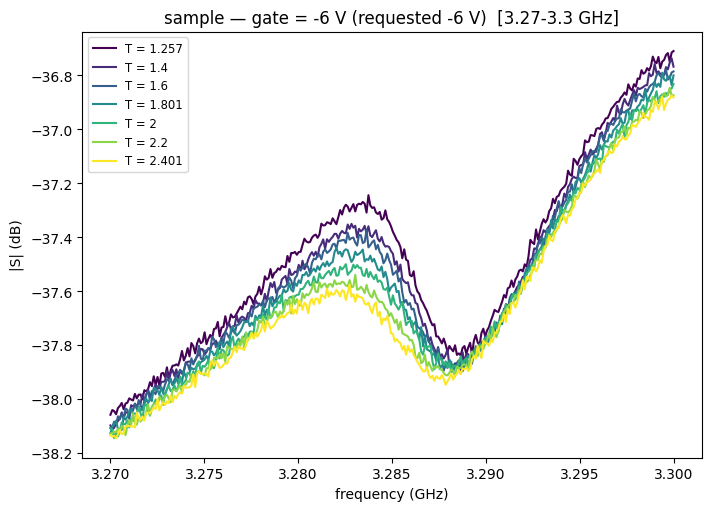

In [30]:
plot_linecuts_vs_temp(sd,'sample',gate=-6,segment=(3.27e9,3.3e9))

In [ ]:
plot_linecuts_vs_temp(sd,'sample',gate=2,segment=(3.27e9,3.3e9),detrend='edges')

# Run #29: Negative gate sweep at base.

In [4]:
ds = qcodes.dataset.load_by_run_spec(captured_run_id=29)

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — run #29  [3.270–3.300 GHz]'}, xlabel='Frequency (GHz)', ylabel='$\\Delta$|$S_{21}$| (dB, detrended)'>)

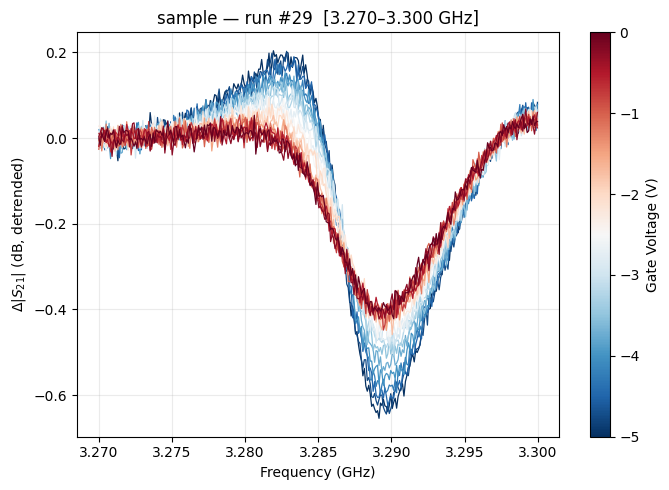

In [28]:
plot_linecuts_segment(ds,name='sample',cmap="RdBu_r",segment=(3.27e9,3.3e9),detrend='edges')

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — run #29'}, xlabel='Gate voltage (V)', ylabel='Frequency (GHz)'>)

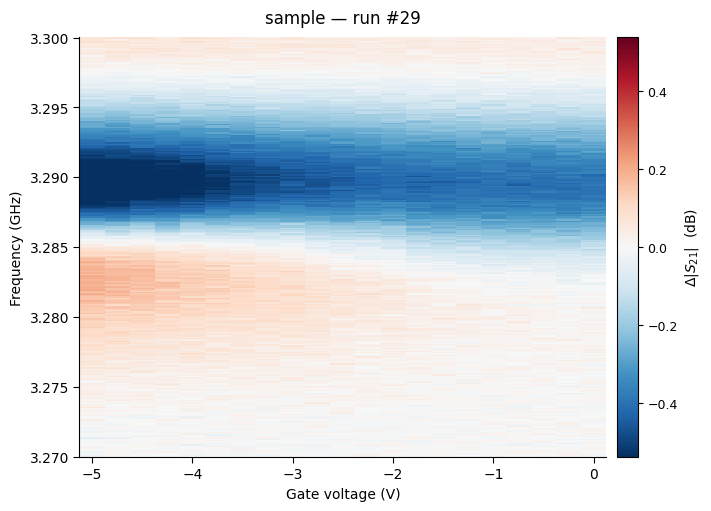

In [27]:
plot_2d(ds,name='sample',segment=(3.27e9,3.3e9),detrend='edges')

# Run #26: temperature sweep at 0-7V on the gate.

In [30]:
ds = qcodes.dataset.load_by_run_spec(captured_run_id=26)

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — measured T = 1.1 (requested 1.2)  [3.27-3.3 GHz, detrended]'}, xlabel='gate voltage (V)', ylabel='frequency (GHz)'>,
 <matplotlib.collections.QuadMesh at 0x241258db410>)

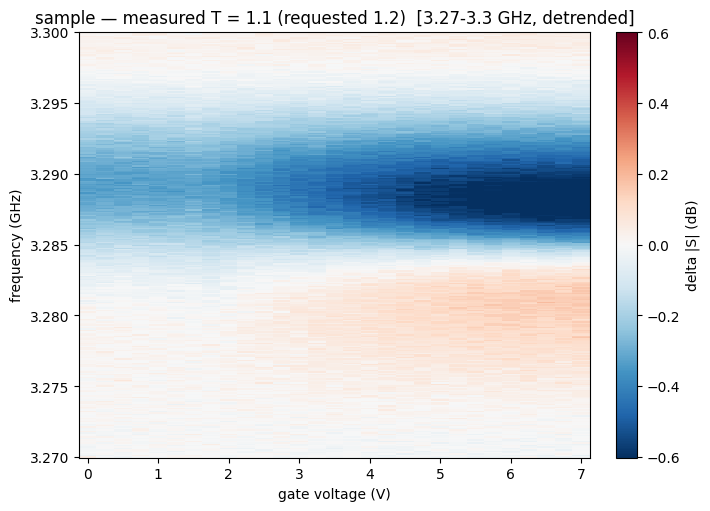

In [38]:
sd = SweepData(ds)
plot_freq_vs_gate(sd,'sample',temperature=1.2,cmap="RdBu_r",segment=(3.27e9,3.3e9),detrend='edges')

In [118]:
ds = load_by_run_spec(captured_run_id=34)
ds.get_parameters()
ds.guid

'5821ba49-0000-0000-0000-01a099b97b41'

In [114]:
print(ds.get_parameter_data().keys())

dict_keys(['lambda2_imag', 'lambda2_real', 'lambda4_imag', 'lambda4_real', 'mode_imag', 'mode_real', 'sample_imag', 'sample_real', 'smu_curr', 'wideband_imag', 'wideband_real'])


In [ ]:
sd = SweepData(ds)

<bound method SweepData.summary of <__main__.SweepData object at 0x0000023E88A06FC0>>

In [109]:
print(sd.summary())

13 temperature steps, 29 gate points
      setpoint      measured      spread
             0       0.01037    0.000437
           100       0.09887      0.0124
           200           0.2      0.0067
           300        0.3003     0.00475
           400        0.4002      0.0106
           500        0.4999      0.0122
           600        0.5996      0.0102
           700        0.7006      0.0168
           800        0.8008      0.0208
           900        0.9008      0.0286
          1000         1.001      0.0612
          1100           1.1      0.0576
          1200         1.056       0.475
bands: lambda2, lambda4, mode, sample, wideband


In [102]:
ds.get_parameter_data().keys()

dict_keys(['lambda2_imag', 'lambda2_real', 'lambda4_imag', 'lambda4_real', 'mode_imag', 'mode_real', 'sample_harm1_imag', 'sample_harm1_real', 'sample_imag', 'sample_real', 'wideband_imag', 'wideband_real'])

In [100]:
ds.snapshot['station']['instruments']['smu']['parameters']['volt']['value']

7.000307

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — run #31  [3.270–3.300 GHz]'}, xlabel='Frequency (GHz)', ylabel='$\\Delta$|$S_{21}$| (dB, detrended)'>)

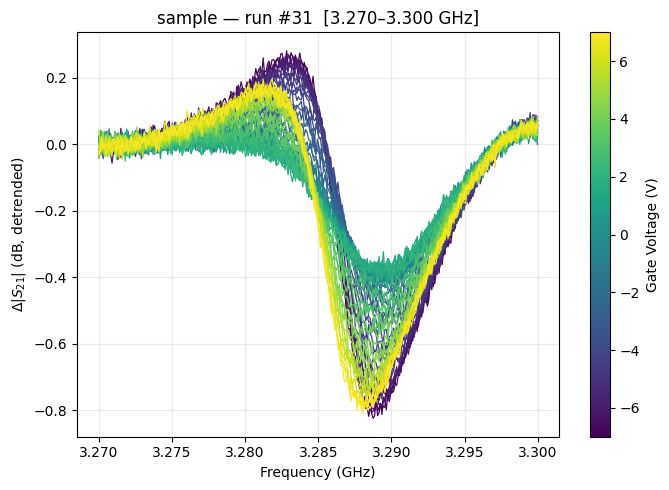

In [76]:
plot_linecuts_segment(ds,'sample',detrend='edges',segment=(3.27e9,3.3e9))

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample_firstharm — run #31  [6.600–6.650 GHz]'}, xlabel='Frequency (GHz)', ylabel='$\\Delta$|$S_{21}$| (dB, detrended)'>)

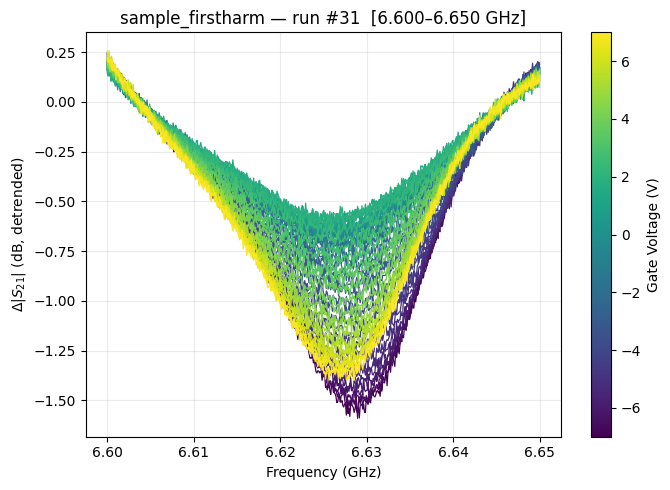

In [82]:
plot_linecuts_segment(ds,'sample_firstharm',segment=(6.6e9,6.65e9),detrend='edges')

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample_firstharm — run #31'}, xlabel='Gate voltage (V)', ylabel='Frequency (GHz)'>)

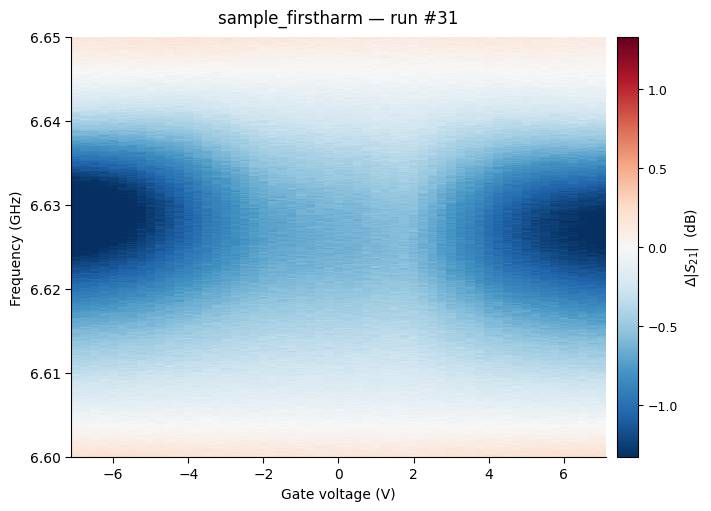

In [83]:
plot_2d(ds,'sample_firstharm',segment=(6.6e9,6.65e9),detrend='edges')

In [ ]:
ds = load_by_run_spec(captured_run_id=26)
sd = SweepData(ds)

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — gate = 2 V (requested 2 V)  [3.27-3.3 GHz, detrended]'}, xlabel='frequency (GHz)', ylabel='delta |S| (dB)'>,
  <matplotlib.lines.Line2D at 0x2412b0e8bc0>])

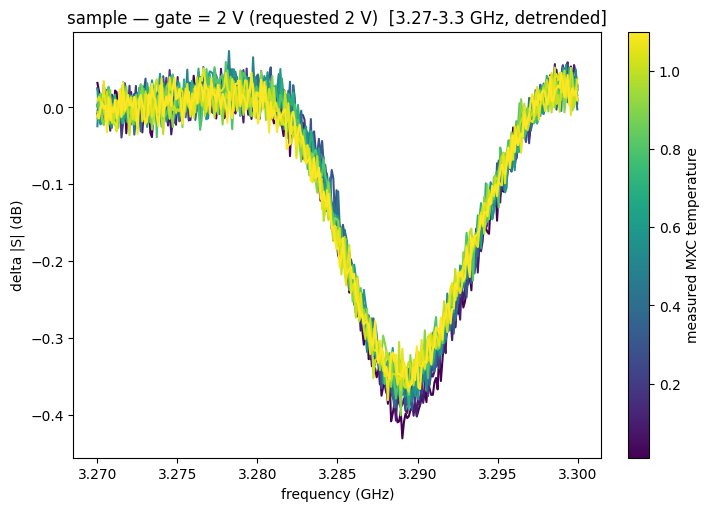

In [88]:
plot_linecuts_vs_temp(sd,'sample',gate=2,segment=(3.27e9,3.3e9),detrend='edges')

(<Figure size 700x500 with 2 Axes>,
 <Axes: title={'center': 'sample — gate = 6 V (requested 6 V)  [3.27-3.3 GHz, detrended]'}, xlabel='frequency (GHz)', ylabel='delta |S| (dB)'>,
  <matplotlib.lines.Line2D at 0x2412b81a8d0>])

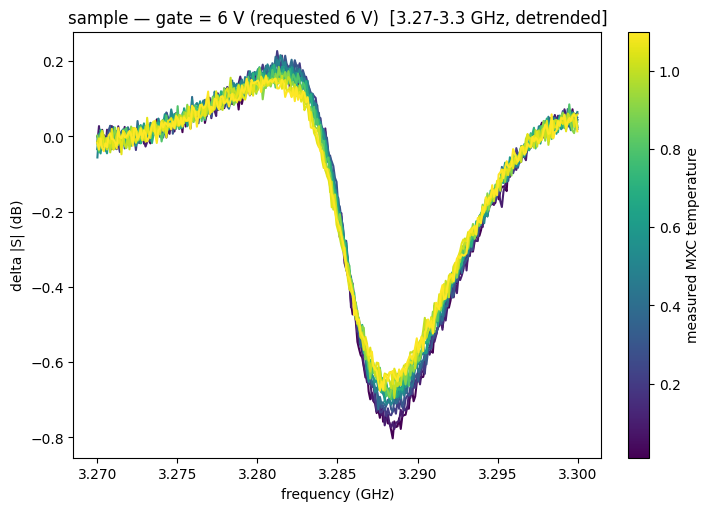

In [90]:
plot_linecuts_vs_temp(sd,'sample',gate=6,segment=(3.27e9,3.3e9),detrend='edges')

In [91]:
import warnings

def load_band_2d_power(ds, name, check_freq=True):
    """Return (power [n], freq [m], s21 [n, m]) for one band."""
    d = ds.get_parameter_data(f"{name}_real", f"{name}_imag")
    re_block, im_block = d[f"{name}_real"], d[f"{name}_imag"]

    power = re_block["vna_power"][:, 0]
    freq_rows = re_block[f"{name}_freq"]
    freq = freq_rows[0, :]
    if check_freq and not np.allclose(freq_rows, freq):
        warnings.warn(
            "the frequency axis is not identical for every power step; "
            "row 0 is being used for all of them"
        )
    s21 = re_block[f"{name}_real"] + 1j * im_block[f"{name}_imag"]
    return power, freq, s21


def _detrend_rows(freq, mag_db, mode="edges", edge_frac=0.15):
    """
    Fit and remove a line in frequency from each row independently.

    freq    : (n_freq,)
    mag_db  : (n_trace, n_freq)

    Returns (detrended, slopes) with slopes in dB/GHz.  A row with fewer than
    two finite points in the fit window is left untouched, with a NaN slope.
    """
    freq = np.asarray(freq, dtype=float)
    y = np.asarray(mag_db, dtype=float)

    if y.ndim != 2 or y.shape[1] != freq.size:
        raise ValueError(
            f"expected mag_db shaped (n_trace, n_freq={freq.size}), got {y.shape}"
        )
    if freq.size < 2:
        raise ValueError("need at least 2 frequency points to fit a line")

    # centre and scale: keeps the fit well conditioned, slope comes out dB/GHz
    x = (freq - freq.mean()) / 1e9

    if mode in (True, "full"):
        fit = np.ones(freq.size, dtype=bool)
    elif mode == "edges":
        n_edge = max(2, int(round(edge_frac * freq.size)))
        if 2 * n_edge >= freq.size:
            warnings.warn(
                f"edge_frac={edge_frac} leaves no gap between the fit windows "
                f"for {freq.size} points; using a full-span fit"
            )
            fit = np.ones(freq.size, dtype=bool)
        else:
            fit = np.zeros(freq.size, dtype=bool)
            fit[:n_edge] = True
            fit[-n_edge:] = True
    else:
        raise ValueError(f"detrend must be None, 'full' or 'edges', got {mode!r}")

    xf, yf = x[fit], y[:, fit].T          # yf: (n_fit, n_trace)
    n_trace = y.shape[0]

    if np.isfinite(yf).all():
        coeffs = np.polyfit(xf, yf, 1)
        slope, intercept = coeffs[0], coeffs[1]
        reported = slope
    else:
        # polyfit propagates NaN across the whole batch, so fit row by row
        slope = np.zeros(n_trace)
        intercept = np.zeros(n_trace)
        reported = np.full(n_trace, np.nan)
        bad = []
        for j in range(n_trace):
            good = np.isfinite(yf[:, j])
            if good.sum() >= 2:
                p = np.polyfit(xf[good], yf[good, j], 1)
                slope[j], intercept[j] = p
                reported[j] = p[0]
            else:
                bad.append(j)
        if bad:
            warnings.warn(
                f"{len(bad)} trace(s) had fewer than 2 finite points in the "
                f"fit window and were left undetrended (first: {bad[0]})"
            )

    baseline = np.outer(slope, x) + intercept[:, None]
    return y - baseline, reported


def plot_linecuts_power(ds, name, cmap="viridis", offset_db=0.0, ax=None,
                        segment=None, detrend=None, edge_frac=0.15):
    power, freq, s21 = load_band_2d_power(ds, name)

    if segment is not None:
        f_lo, f_hi = sorted(float(v) for v in segment)
        if max(abs(f_lo), abs(f_hi)) < 1e6 < np.nanmax(np.abs(freq)):
            raise ValueError(
                f"segment {segment!r} looks like GHz but the frequency axis "
                f"is in Hz; pass e.g. (6e9, 7e9)"
            )
        mask = (freq >= f_lo) & (freq <= f_hi)
        if mask.sum() < 2:
            raise ValueError(
                f"segment ({f_lo:.6g}, {f_hi:.6g}) Hz selects {mask.sum()} "
                f"points; the band covers {freq.min():.6g}-{freq.max():.6g} Hz"
            )
        freq = freq[mask]
        s21 = s21[:, mask]

    mag_db = 20 * np.log10(np.abs(s21))

    slopes = None
    if detrend:
        mag_db, slopes = _detrend_rows(freq, mag_db, detrend, edge_frac)

    norm = colors.Normalize(vmin=power.min(), vmax=power.max())
    sm = cm.ScalarMappable(norm=norm, cmap=cmap)

    if ax is None:
        fig, ax = plt.subplots(figsize=(7, 5))
    else:
        fig = ax.figure

    for i, p in enumerate(power):
        ax.plot(freq / 1e9, mag_db[i] + i * offset_db,
                color=sm.to_rgba(p), lw=0.9)

    ax.set_xlabel("Frequency (GHz)")
    ylabel = r"$\Delta$|$S_{21}$| (dB)" if detrend else "|$S_{21}$| (dB)"
    ax.set_ylabel(ylabel + (" + offset" if offset_db else ""))

    title = f"{name} — run #{ds.captured_run_id}"
    bits = []
    if segment is not None:
        bits.append(f"{f_lo/1e9:.4g}-{f_hi/1e9:.4g} GHz")
    if detrend:
        bits.append("detrended" if detrend == "edges" else f"detrended/{detrend}")
    if bits:
        title += f"  [{', '.join(bits)}]"
    ax.set_title(title)

    ax.grid(alpha=0.25)

    cb = fig.colorbar(sm, ax=ax)
    cb.set_label("Power (dBm)")
    fig.tight_layout()

    ax.detrend_slopes = slopes
    return fig, ax